# CDM Spike Evolution Around a SMBH Binary

## Physical motivation

The final parsec problem asks how a supermassive black hole (SMBH) binary can continue losing orbital energy once stellar and gas-driven hardening become inefficient near parsec scales. In this exploratory model, the binary is embedded in a finite cold dark matter (CDM) spike. CDM particles interact gravitationally with the SMBHs and can be ejected through slingshot-like encounters, carrying away energy and angular momentum.

The main observable is the SMBH separation as a function of time. If the CDM spike is depleted, the separation stops decreasing efficiently and approaches a plateau. That plateau is interpreted here as a numerical estimate of the stalling distance.

## What this notebook does

- Builds a two-SMBH `rebound` simulation.
- Adds a finite set of massive tracer particles representing the CDM spike.
- Evolves the system and records the SMBH separation.
- Smooths the separation curve to show the hardening trend.
- Optionally renders a 2D movie of the particle distribution.


# Imports and Binary Setup

This section imports the required packages, creates the `rebound.Simulation`, sets the units to years, AU, and solar masses, and initializes the SMBH binary. The initial separation is 206265 AU, corresponding to 1 pc.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import imageio.v3 as iio

from cdm_spike_utils import (
    add_radial_uniform_spike,
    configure_smbh_collisions,
    create_smbh_binary,
    moving_average,
    schwarzschild_radius_au,
)

# Define the SMBH binary parameters.
M_1 = 3e9
q = 1

sim, black_hole_1, black_hole_2, M_2, M_total = create_smbh_binary(M_1, q=q)


# CDM Spike Initialization

The CDM spike is represented by a finite number of massive tracer particles. Each particle is placed in a spherical shell around the binary center of mass and assigned a tangential velocity close to the circular velocity at its radius.

This is a simplified numerical model rather than a fully self-consistent equilibrium distribution. It is useful for exploring how repeated SMBH-particle encounters change the binary separation.


In [2]:
# Define the CDM spike.
N_particles = 60
M_spike_total = 0.8 * M_1
radius_spike = 400000
bh_distance = []

m_single_dm = add_radial_uniform_spike(
    sim,
    n_particles=N_particles,
    total_spike_mass=M_spike_total,
    m_central=M_total,
    r_min=1000,
    r_max=radius_spike,
    seed=0,
)

print(f"Generated {N_particles} CDM particles with mass {m_single_dm:.2e} Msun each.")


Generated 60 CDM particles with mass 4.00e+07 Msun each.


# Frame Generation

The next function saves a 2D projection of the simulation state. The origin is kept in the center-of-mass frame and the plot limits are fixed, so each frame can be compared directly when building the movie.


In [3]:
os.makedirs("spike_frames", exist_ok=True)

# Shift the reference frame so the center of mass is at the origin
sim.move_to_com()

def frame(simulation, frame_number):
    # Get X and Y coordinates for Dark Matter (skipping the first 2 particles)
    x_dm = np.array([b.x for b in simulation.particles[2:]]) 
    y_dm = np.array([b.y for b in simulation.particles[2:]]) 
    
    # We get the coordinates of the BH
    x_bh = np.array([b.x for b in simulation.particles[:2]]) 
    y_bh = np.array([b.y for b in simulation.particles[:2]]) 
    
    # Create the plot
    plt.style.use('dark_background') 
    plt.figure(figsize=(8,8))
    
    # Plot DM as tiny blue dots, and BH as big red stars
    plt.scatter(x_dm, y_dm, s=10, color='cyan', alpha=0.6, label='CDM Particles')
    plt.scatter(x_bh, y_bh, s=150, color='red', marker='*', label='SMBH')
    
    # Keep fixed plot limits so frames can be compared directly
    plt.xlim(-500000, 500000)
    plt.ylim(-500000, 500000)
    plt.title(f"Simulation Time: {simulation.t:,.0f} Years", fontsize=14)
    plt.legend(loc='upper right')
    
    filename = f"spike_frames/frame_{frame_number:04d}.png"
    
    plt.savefig(filename, dpi=100)
    
    plt.close() # Free the figure memory


# Collision Prescription

Collisions are enabled so that particles passing inside the SMBH Schwarzschild radius are merged into the SMBH. This prevents unresolved close passages from dominating the integration.


In [4]:
R_sch = schwarzschild_radius_au(M_1)
print(f"The Schwarzschild radius is {R_sch} AU")

configure_smbh_collisions(sim, R_sch, softening=True)


The Schwarzschild radius is 59.238711673042346 AU


# Time Integration

The simulation is advanced in fixed output intervals. At each interval, the notebook saves a frame and records the instantaneous separation between the two SMBHs.


In [5]:
# Execute the simulation
N_years = 20000
N_frames = 600
t_array = np.linspace(0, N_years, N_frames)
Delta_time = N_years/N_frames
print(f"Running the simulation for {N_years} years")

for i in range(N_frames):
    next_time = sim.t + Delta_time
    sim.integrate(next_time)
    
    # Save the frame
    frame(sim, i)
    
    # Print progress during the run
    if i % 100 == 0:
        print(f"Rendered frame {i} / {N_frames}")
        
    # Save the instantaneous SMBH separation
    bh_distance.append(black_hole_1 ** black_hole_2)
    
print("Simulation complete")

    


Running the simulation for 20000 years
Rendered frame 0 / 600
Rendered frame 100 / 600
Rendered frame 200 / 600
Rendered frame 300 / 600
Rendered frame 400 / 600
Rendered frame 500 / 600
Simulation complete


# SMBH Separation Versus Time

The SMBH separation is converted from AU to parsec and plotted against simulation time. A decreasing curve indicates binary hardening driven by interactions with the CDM spike. A late-time plateau indicates that the spike has become inefficient at extracting additional orbital energy.


Text(0, 0.5, 'Distance between the BHs (pc)')

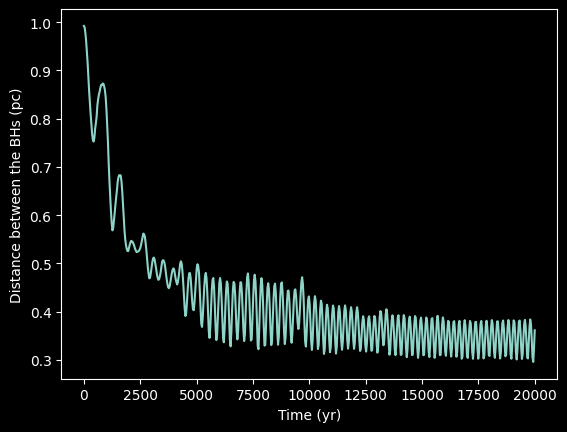

In [6]:
# Convert the SMBH separation from AU to parsec
bh_distance = np.array(bh_distance) / 206265
plt.plot(t_array, bh_distance)
plt.xlabel('Time (yr)')
plt.ylabel('Distance between the BHs (pc)')


# Smoothed Separation Curve

The raw separation contains orbital oscillations because the binary orbit is not perfectly circular. A moving average makes the secular hardening trend easier to identify.


Text(0, 0.5, 'Distance between the BHs (pc)')

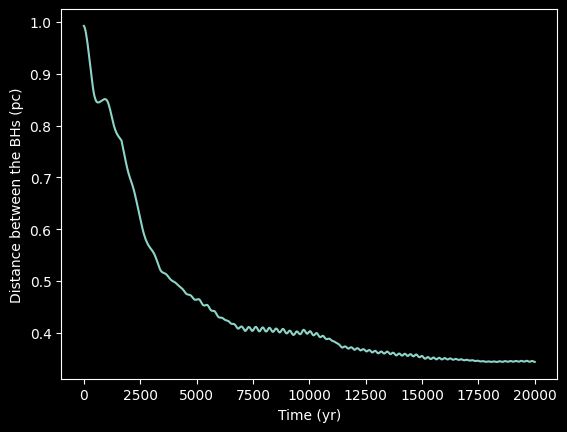

In [7]:
avg_distance = moving_average(bh_distance, window=50)

plt.plot(t_array, avg_distance)
plt.xlabel('Time (yr)')
plt.ylabel('Distance between the BHs (pc)')


# Video Export

The saved PNG frames are sorted and combined into an MP4 video. This is optional and can be skipped if only the separation curve is needed.


In [8]:
frame_folder = "spike_frames"
video_filename = "dark_matter_spike.mp4"
fps = 20

image_files = [f for f in os.listdir(frame_folder) if f.endswith('.png')]
image_files.sort() # to sort the frames

# Create the video

with iio.imopen(video_filename, "w", plugin="pyav") as writer:
    
    for filename in image_files:
        file_path = os.path.join(frame_folder, filename)
        
        # Read the image data
        image_data = iio.imread(file_path)
        
        # Strip the alpha channel (RGBA -> RGB)
        image_data = image_data[:, :, :3]
        
        # Write it to the video stream, explicitly telling it this is ONE frame
        writer.write(image_data, codec="libx264", fps=fps, is_batch=False)

print(f"Success! Your simulation movie is saved as: {video_filename}")


Success! Your simulation movie is saved as: dark_matter_spike.mp4


# Embedded Video

Display the generated MP4 inside the notebook.


In [9]:
from IPython.display import Video

# Display the video inside the notebook
Video(video_filename, embed=True, width=700)
